/tmp/ipykernel_2585/3746292519.py:54: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_m

Dropped 0.5% entries from factor data: 0.5% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,0.045381,1.055812,0.304986,0.243088,17875,20.180410
2,0.051740,1.058714,0.419721,0.279333,17660,19.937681
3,0.052126,1.062632,0.509582,0.289675,17588,19.856395
4,0.052477,1.065522,0.611334,0.282154,17660,19.937681
5,0.059029,1.088561,0.799816,0.242711,17793,20.087834


Returns Analysis


,1D,5D,10D
Ann. alpha,0.264,0.266,0.214
beta,-0.016,-0.016,-0.002
Mean Period Wise Return Top Quantile (bps),21.239,18.412,14.030
Mean Period Wise Return Bottom Quantile (bps),-5.473,-7.495,-7.255
Mean Period Wise Spread (bps),26.712,25.237,20.869


<Figure size 640x480 with 0 Axes>

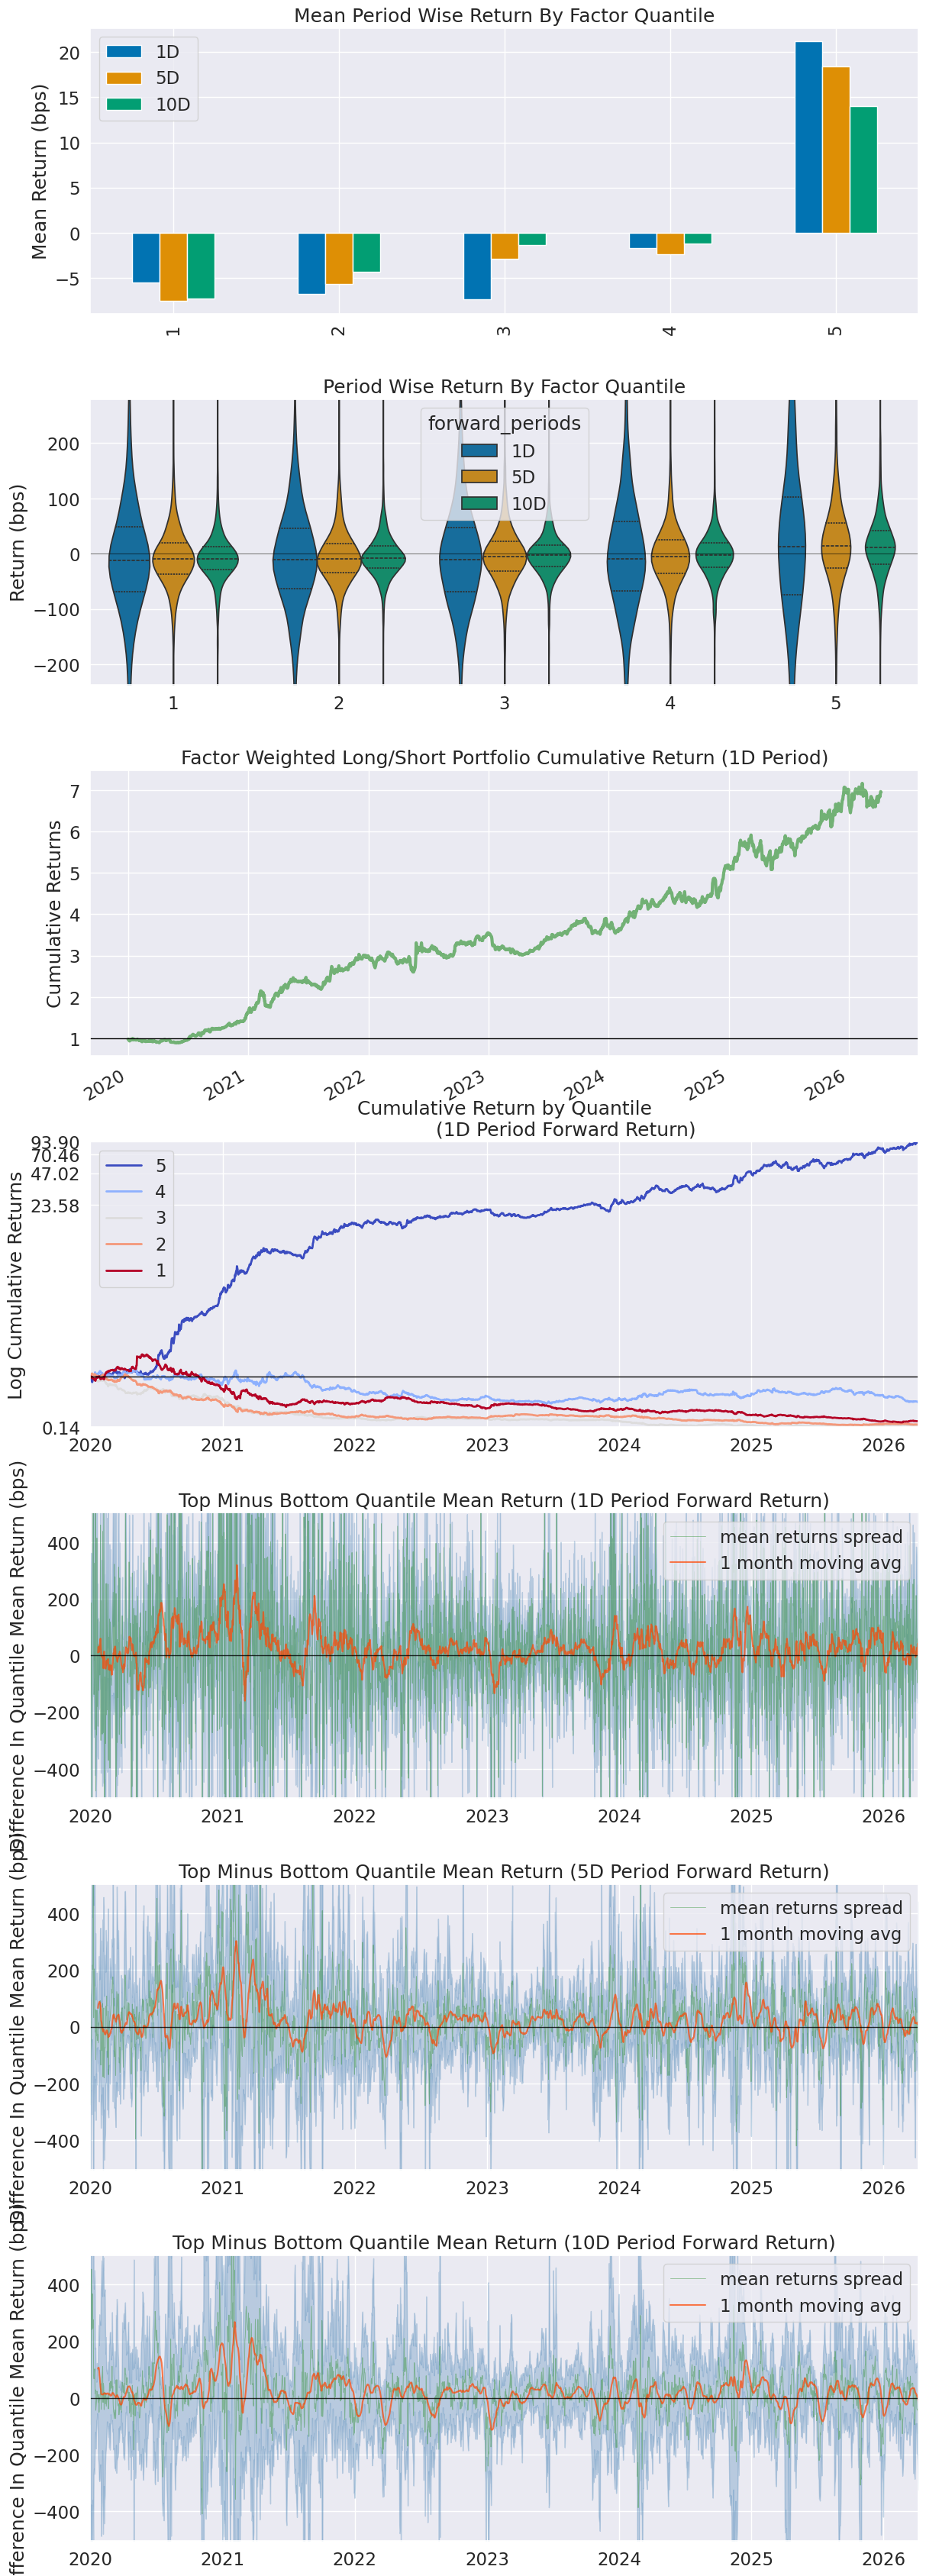

Information Analysis


,1D,5D,10D
IC Mean,-0.005,0.023,0.035
IC Std.,0.231,0.233,0.234
Risk-Adjusted IC,-0.023,0.100,0.149
t-stat(IC),-1.088,4.790,7.136
p-value(IC),0.277,0.000,0.000
IC Skew,0.030,-0.076,-0.150
IC Kurtosis,-0.384,-0.174,-0.171


/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


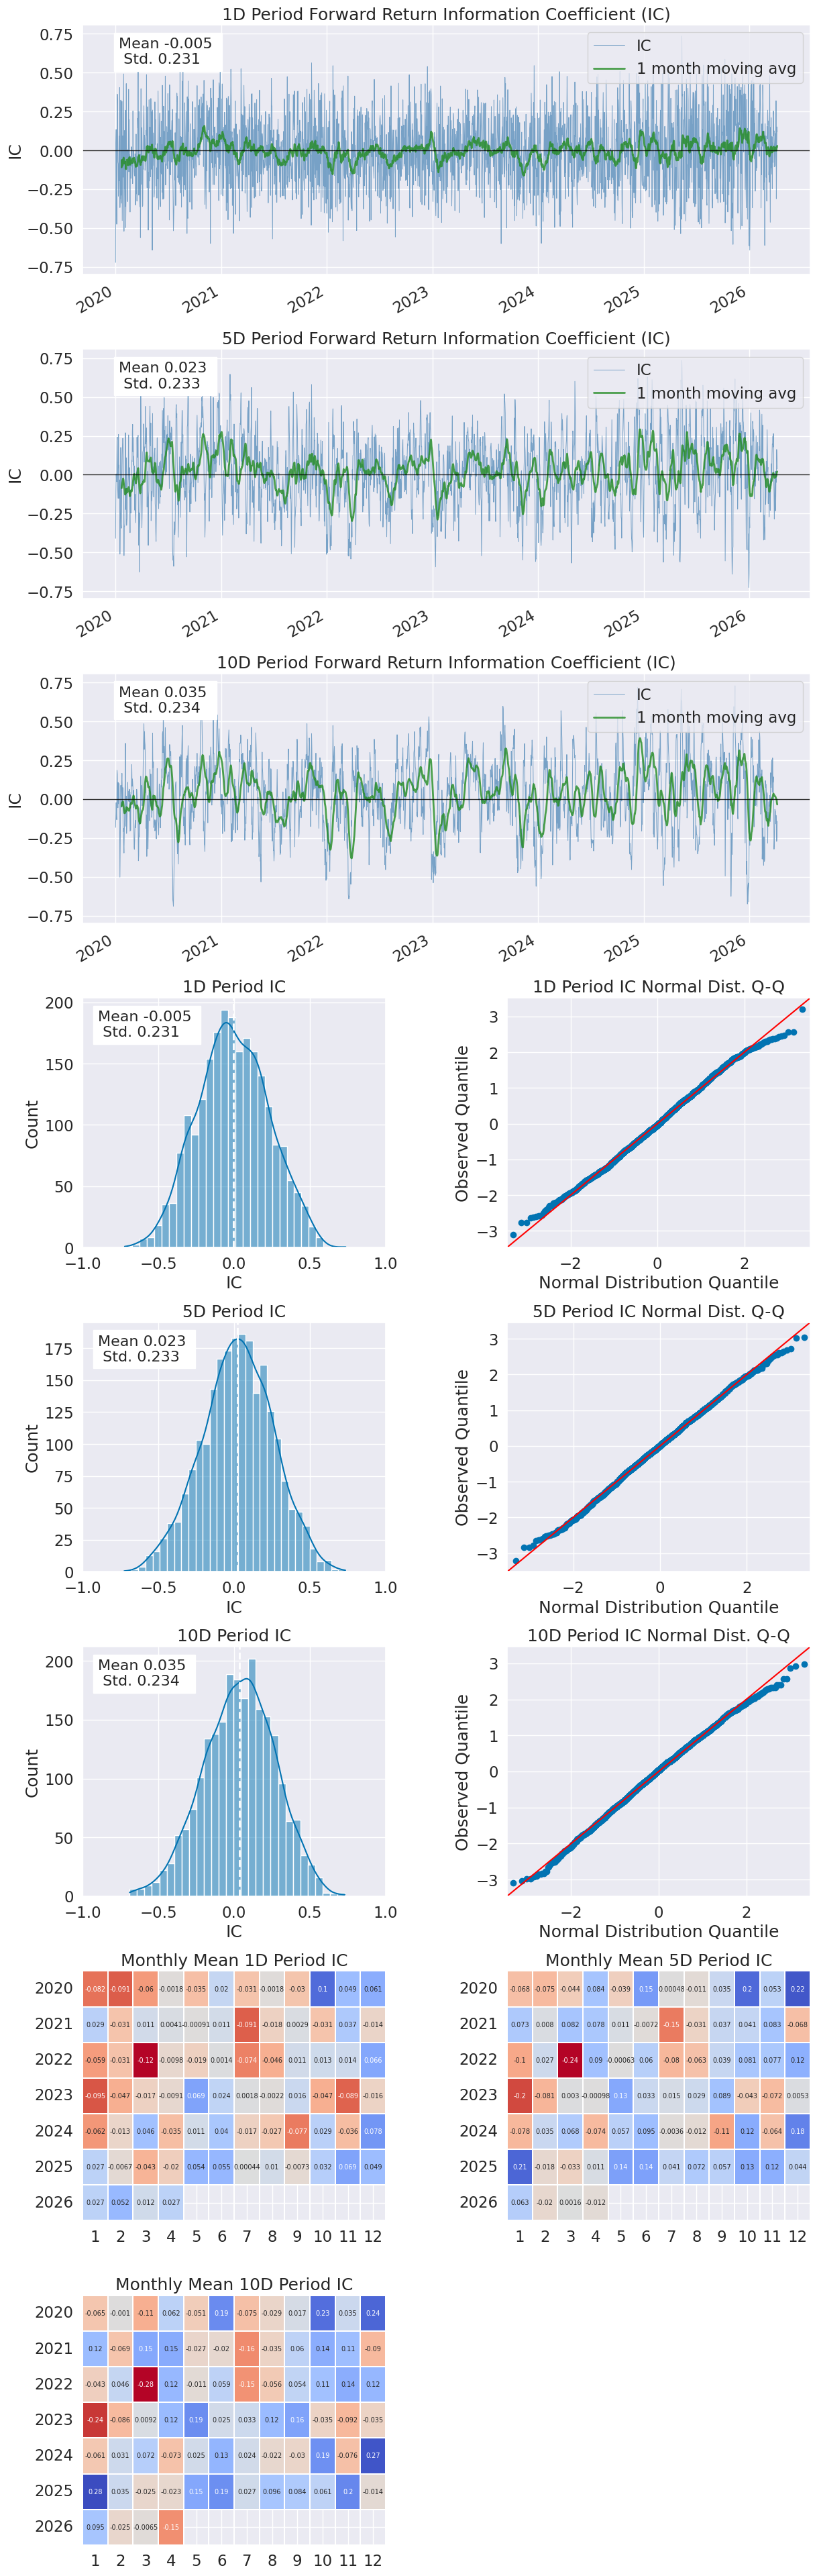

/opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages/alphalens/utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.191,0.336,0.428
Quantile 2 Mean Turnover,0.359,0.546,0.628
Quantile 3 Mean Turnover,0.374,0.576,0.667
Quantile 4 Mean Turnover,0.321,0.525,0.618
Quantile 5 Mean Turnover,0.161,0.310,0.405


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.946,0.844,0.761


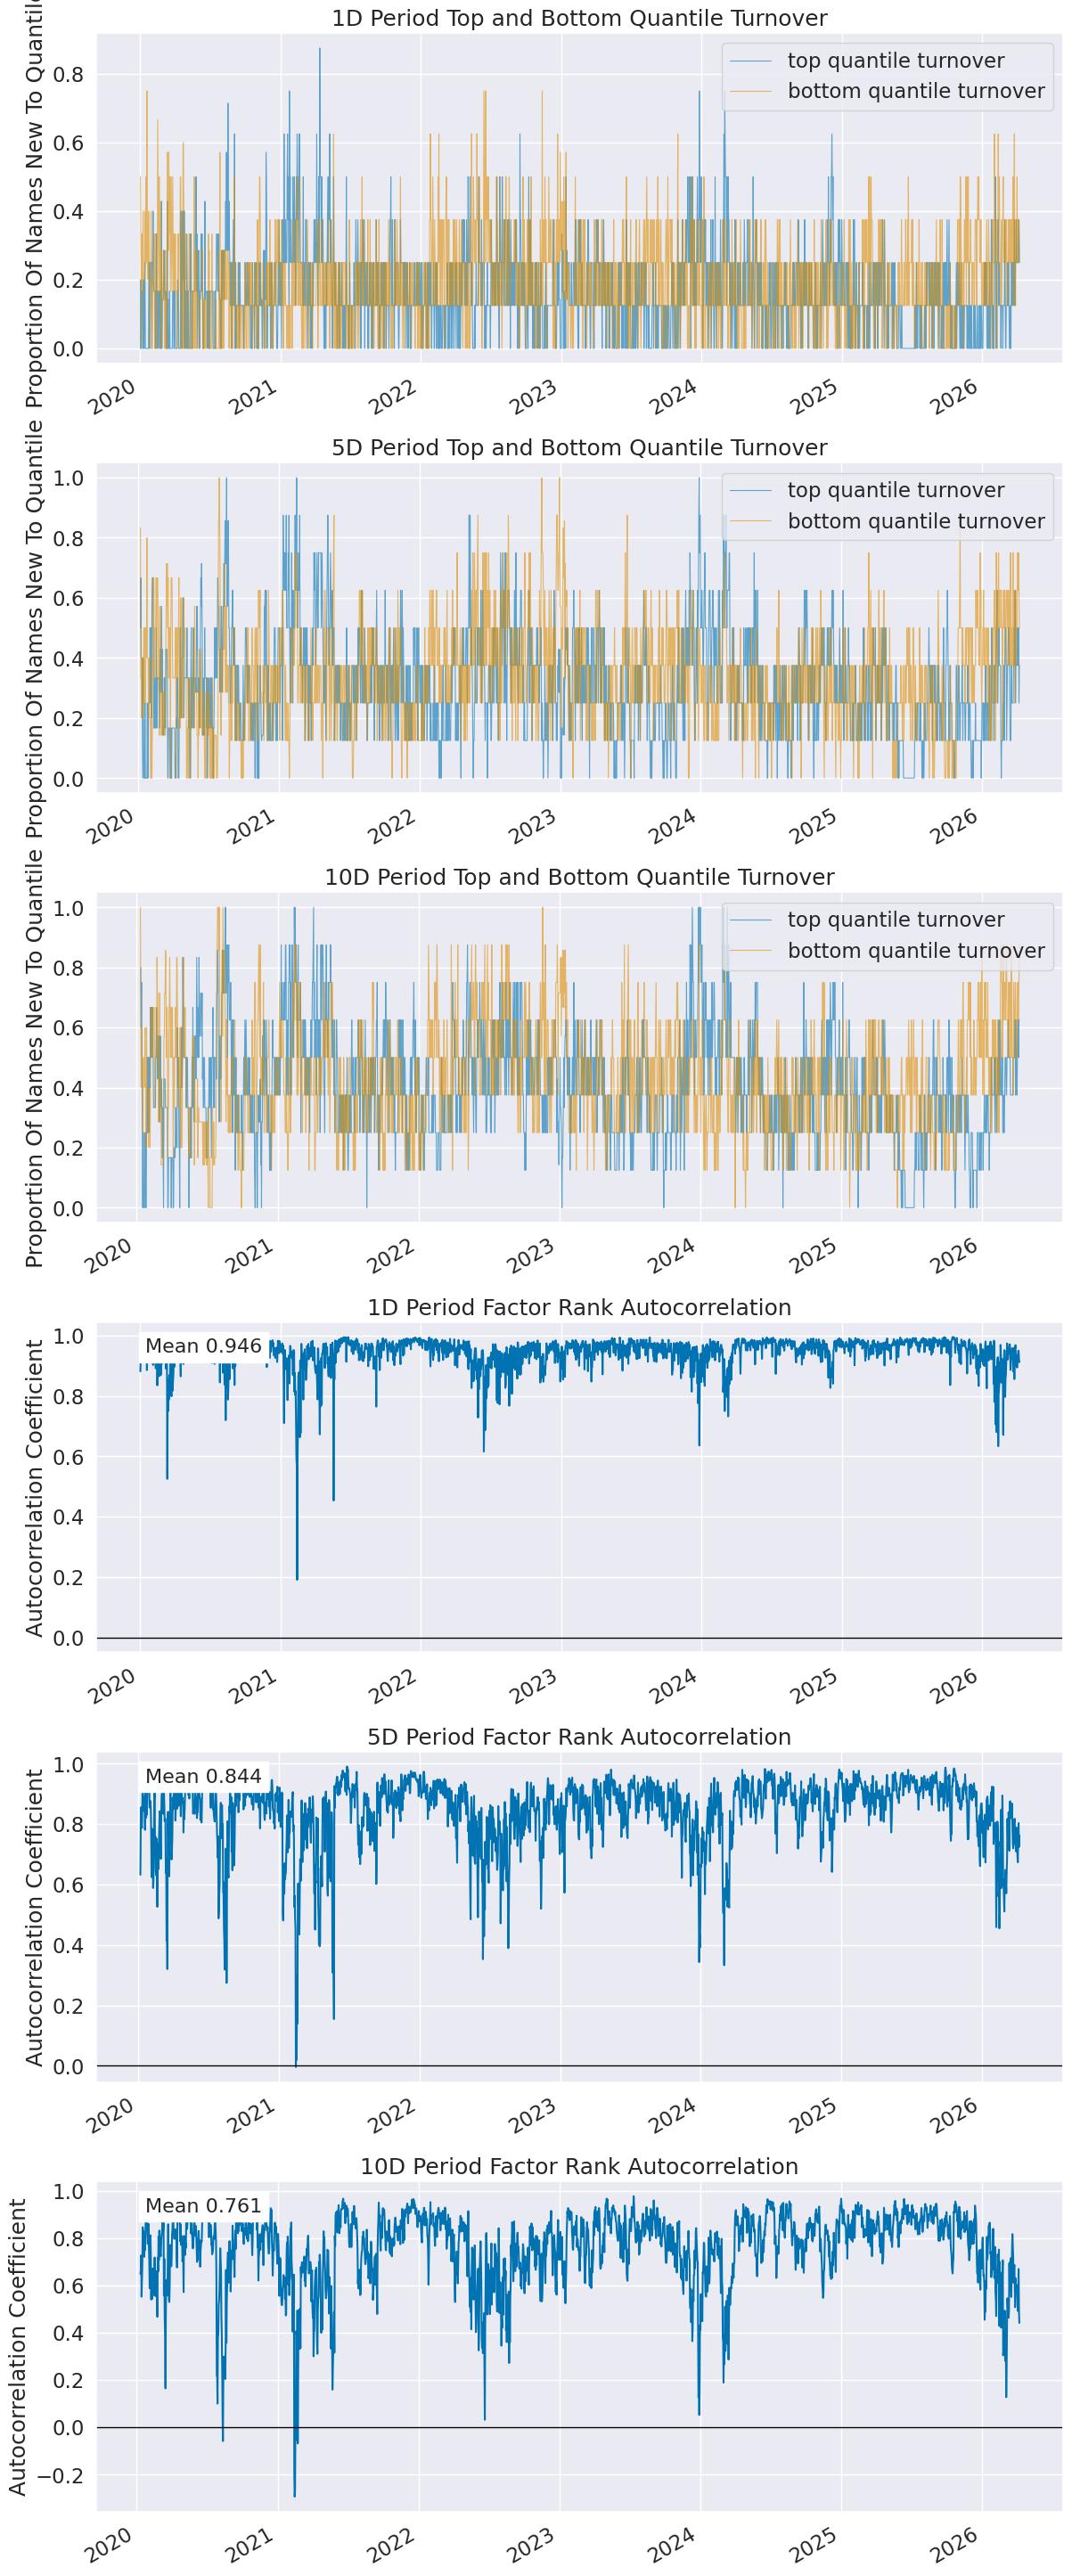

In [1]:
# AUTO-GENERATED by scripts/generate_factor_notebooks.py from
# scripts/factors_catalog.py -- do not edit by hand. Re-run the
# generator (or the "Generate Notebooks" workflow) to refresh.
import sys
from pathlib import Path

_repo_root = Path.cwd()
while not (_repo_root / "analysis").is_dir() and _repo_root != _repo_root.parent:
    _repo_root = _repo_root.parent
sys.path.insert(0, str(_repo_root))

from unravel_client import (
    get_historical_universe,
    get_portfolio_factors_historical,
    get_prices,
    get_tickers,
)

from analysis.alphalens import factor_analysis
from analysis.utils import get_env

UNRAVEL_API_KEY = get_env("UNRAVEL_API_KEY")

# Polaris -- portfolio polaris.40
portfolio = "polaris"
universe_size = "40"

available_tickers = get_tickers(
    id=portfolio,
    api_key=UNRAVEL_API_KEY,
    universe_size=universe_size,
    exchange=None,
)
historical_factors = get_portfolio_factors_historical(
    id=portfolio, tickers=available_tickers, api_key=UNRAVEL_API_KEY
)
underlying = get_prices(tickers=available_tickers, api_key=UNRAVEL_API_KEY)

# Restrict the analysis to the *dynamic* point-in-time universe rather than
# every ticker that was ever tradeable. get_historical_universe returns a
# boolean membership matrix (dates x tickers); masking the raw factor with it
# drops each asset on the days it was out of universe, so AlphaLens scores
# the factor on the universe we actually trade.
universe = get_historical_universe(
    size=universe_size,
    api_key=UNRAVEL_API_KEY,
    start_date=str(historical_factors.index.min().date()),
    end_date=str(historical_factors.index.max().date()),
)
membership = (
    universe.reindex(index=historical_factors.index)
    .ffill()
    .reindex(columns=historical_factors.columns)
    .fillna(False)
    .astype(bool)
)
restricted_factors = historical_factors.where(membership)

columns_intersection = restricted_factors.columns.intersection(underlying.columns)
factor_analysis(restricted_factors[columns_intersection], underlying)